In [1]:
# ============================================================
# Ensemble-Learning Approach for Detecting Attacks in
# Smart Industrial Environments using the X-IIoTID Dataset
# ============================================================

# This notebook implements an ensemble-learning framework for
# attack detection in IIoT environments using the X-IIoTID dataset.
#
# Main pipeline:
# 1) Data loading and cleaning
# 2) Missing-value imputation
# 3) Categorical encoding
# 4) Min-Max normalization
# 5) SMOTE for class balancing
# 6) PCA for dimensionality reduction
# 7) Training RF, ET, KNN, and Soft Voting Ensemble
# 8) Evaluation using Accuracy, Precision, Recall, F1-score, Error Rate
#
# The notebook supports:
# - Binary classification
# - Multiclass classification
#
# Recommended file name:
# ensemble_attack_detection_xiiotid.ipynb

In [2]:
# =========================
# 1. Setup and Installation
# =========================
!pip install -q imbalanced-learn scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 7.5 MB/s eta 0:00:00


In [3]:
# =========================
# 2. Imports and Parameters
# =========================
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# -------------------------
# Experiment Configuration
# -------------------------
RANDOM_STATE = 42
TEST_SIZE = 0.30
PCA_COMPONENTS = 0.95

# Choose task type: 'binary' or 'multiclass'
TASK_TYPE = 'multiclass'

# Dataset path
DATASET_PATH = '/content/drive/MyDrive/MQTT/X-IIoTID dataset.csv'

# Explicit target column for reproducibility
TARGET_COLUMN = 'class1'

# Label used for normal traffic in binary classification
# Change this if your dataset uses a different normal label
NORMAL_LABEL_CANDIDATES = ['Normal', 'Benign', 'normal', 'BENIGN']

print("✓ Libraries imported successfully")
print(f"✓ TASK_TYPE = {TASK_TYPE}")
print(f"✓ DATASET_PATH = {DATASET_PATH}")
print(f"✓ TARGET_COLUMN = {TARGET_COLUMN}")

✓ Libraries imported successfully
✓ TASK_TYPE = multiclass
✓ DATASET_PATH = /content/drive/MyDrive/MQTT/X-IIoTID dataset.csv
✓ TARGET_COLUMN = class1


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
# =================
# 3. Load Dataset
# =================
print("Loading dataset...")

try:
    df = pd.read_csv(DATASET_PATH, low_memory=False)
except pd.errors.ParserError:
    print("⚠ Detected malformed CSV. Loading with bad-line skipping...")
    df = pd.read_csv(DATASET_PATH, low_memory=False, on_bad_lines='skip')

print("✓ Dataset loaded successfully")
print(f"Shape: {df.shape}")
print(f"First 10 columns: {df.columns.tolist()[:10]}")

if TARGET_COLUMN not in df.columns:
    print(f"⚠ Target column '{TARGET_COLUMN}' not found. Available columns are: {df.columns.tolist()}")
    raise ValueError(f"Target column '{TARGET_COLUMN}' not found in dataset.")

print("\nSample rows:")
display(df.head())

Loading dataset...
✓ Dataset loaded successfully
Shape: (820834, 68)
First 10 columns: ['Date', 'Timestamp', 'Scr_IP', 'Scr_port', 'Des_IP', 'Des_port', 'Protocol', 'Service', 'Duration', 'Scr_bytes']

Sample rows:


,Date,Timestamp,Scr_IP,Scr_port,Des_IP,Des_port,Protocol,Service,Duration,Scr_bytes,...,OSSEC_alert_level,Login_attempt,Succesful_login,File_activity,Process_activity,read_write_physical.process,is_privileged,class1,class2,class3
0,9/01/2020,1578540956,192.168.2.199,49278,192.168.2.10,80,tcp,http,0.67369,13437,...,5,0,0,0,0,0,0,Scanning_vulnerability,Reconnaissance,Attack
1,13/01/2020,1578871873,10.0.1.5,39769,131.236.3.92,53,udp,dns,0.000083,78,...,0,0,0,0,0,0,0,Normal,Normal,Normal
2,9/01/2020,1578522486,172.24.1.80,59050,172.24.1.1,53,udp,dns,0.000132,38,...,0,0,0,0,0,0,0,Normal,Normal,Normal
3,27/02/2020,1582757640,192.168.2.196,37966,192.168.2.10,1880,tcp,websocket,9.378481,1121,...,0,1,1,1,1,1,1,Normal,Normal,Normal
4,16/12/2019,1576452612,172.24.1.80,38233,172.24.1.1,53,udp,dns,0.000074,-,...,0,0,0,0,0,0,0,Normal,Normal,Normal


Target column: class1

Original class distribution:
class1
Normal                            421417
RDOS                              141261
Scanning_vulnerability             52852
Generic_scanning                   50277
BruteForce                         47241
MQTT_cloud_broker_subscription     23524
Discovering_resources              23148
Exfiltration                       22134
insider_malcious                   17447
Modbus_register_reading             5953
False_data_injection                5094
C&C                                 2863
Dictionary                          2572
TCP Relay                           2119
fuzzing                             1313
Reverse_shell                       1016
crypto-ransomware                    458
MitM                                 117
Fake_notification                     28
Name: count, dtype: int64

✓ Removed 0 rows with missing target values
Dataset size after cleaning: 820834

✓ Multiclass setting retained

Class distribution afte

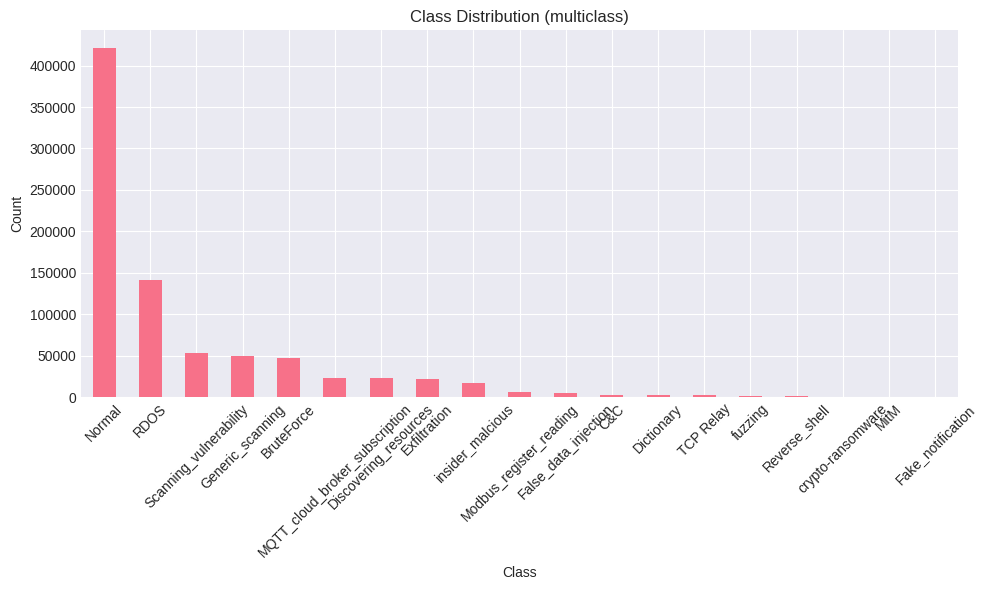

In [6]:
# ==========================
# 4. Clean and Prepare Labels
# ==========================
target_col = TARGET_COLUMN

print(f"Target column: {target_col}")
print("\nOriginal class distribution:")
print(df[target_col].value_counts(dropna=False))

# Remove rows with missing target
original_size = len(df)
df = df.dropna(subset=[target_col]).copy()
cleaned_size = len(df)

print(f"\n✓ Removed {original_size - cleaned_size} rows with missing target values")
print(f"Dataset size after cleaning: {cleaned_size}")

# Convert to binary if requested
if TASK_TYPE == 'binary':
    normal_found = None
    unique_labels = df[target_col].astype(str).unique().tolist()

    for candidate in NORMAL_LABEL_CANDIDATES:
        if candidate in unique_labels:
            normal_found = candidate
            break

    if normal_found is None:
        raise ValueError(
            f"Could not identify the normal label automatically. "
            f"Available labels: {unique_labels}\n"
            f"Please update NORMAL_LABEL_CANDIDATES."
        )

    df[target_col] = df[target_col].astype(str).apply(
        lambda x: 'Normal' if x == normal_found else 'Attack'
    )
    print(f"\n✓ Binary conversion applied using normal label: {normal_found}")

elif TASK_TYPE == 'multiclass':
    df[target_col] = df[target_col].astype(str)
    print("\n✓ Multiclass setting retained")
else:
    raise ValueError("TASK_TYPE must be either 'binary' or 'multiclass'")

print("\nClass distribution after task preparation:")
class_dist = df[target_col].value_counts()
print(class_dist)

plt.figure(figsize=(10, 6))
class_dist.plot(kind='bar')
plt.title(f'Class Distribution ({TASK_TYPE})')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# ==========================
# 5. Data Preprocessor Class
# ==========================
class DataPreprocessor:
    def __init__(self, n_components=0.95, random_state=42):
        self.imputer = SimpleImputer(strategy='mean')
        self.scaler = MinMaxScaler()
        self.pca = PCA(n_components=n_components)
        self.smote = SMOTE(random_state=random_state)
        self.label_encoders = {}
        self.target_encoder = None

    def preprocess(self, df, target_col='class', is_training=True):
        X = df.drop(columns=[target_col]).copy()
        y = df[target_col].copy()

        # Encode target
        if is_training:
            self.target_encoder = LabelEncoder()
            y_encoded = self.target_encoder.fit_transform(y.astype(str))
            print(f"Target classes: {list(self.target_encoder.classes_)}")
        else:
            if self.target_encoder is None:
                raise ValueError("Target encoder not fitted.")
            y_encoded = self.target_encoder.transform(y.astype(str))

        # Separate columns
        numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

        # Impute numeric columns
        if len(numeric_cols) > 0:
            if is_training:
                X[numeric_cols] = self.imputer.fit_transform(X[numeric_cols])
            else:
                X[numeric_cols] = self.imputer.transform(X[numeric_cols])

        # Encode categorical columns
        for col in categorical_cols:
            if is_training:
                le = LabelEncoder()
                X[col] = le.fit_transform(X[col].astype(str))
                self.label_encoders[col] = le
            else:
                le = self.label_encoders.get(col)
                if le is None:
                    raise ValueError(f"Missing label encoder for column: {col}")

                known_classes = set(le.classes_)
                X[col] = X[col].astype(str).apply(
                    lambda v: v if v in known_classes else le.classes_[0]
                )
                X[col] = le.transform(X[col])

        # Scale
        if is_training:
            X_scaled = self.scaler.fit_transform(X)
        else:
            X_scaled = self.scaler.transform(X)

        # SMOTE only on training data
        if is_training:
            print(f"Original encoded class distribution: {np.bincount(y_encoded)}")
            X_balanced, y_balanced = self.smote.fit_resample(X_scaled, y_encoded)
            print(f"Balanced encoded class distribution: {np.bincount(y_balanced)}")
        else:
            X_balanced, y_balanced = X_scaled, y_encoded

        # PCA
        if is_training:
            X_pca = self.pca.fit_transform(X_balanced)
            explained = np.sum(self.pca.explained_variance_ratio_)
            print(f"PCA reduced features to {self.pca.n_components_} components")
            print(f"Explained variance: {explained:.4f}")
        else:
            X_pca = self.pca.transform(X_balanced)

        return X_pca, y_balanced

print("✓ DataPreprocessor class defined")

✓ DataPreprocessor class defined


In [8]:
# ==========================
# 6. Split and Preprocess Data
# ==========================
print("Splitting data into train and test sets...")

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[target_col]
)

print(f"✓ Training set shape: {train_df.shape}")
print(f"✓ Testing set shape: {test_df.shape}")

preprocessor = DataPreprocessor(
    n_components=PCA_COMPONENTS,
    random_state=RANDOM_STATE
)

print("\nPreprocessing training data...")
train_start = time.time()
X_train, y_train = preprocessor.preprocess(train_df, target_col=target_col, is_training=True)
train_prep_time = time.time() - train_start

print("\nPreprocessing test data...")
test_start = time.time()
X_test, y_test = preprocessor.preprocess(test_df, target_col=target_col, is_training=False)
test_prep_time = time.time() - test_start

print(f"\n✓ Training preprocessing time: {train_prep_time:.2f} sec")
print(f"✓ Testing preprocessing time: {test_prep_time:.2f} sec")
print(f"✓ X_train shape: {X_train.shape}")
print(f"✓ X_test shape: {X_test.shape}")

Splitting data into train and test sets...
✓ Training set shape: (574583, 68)
✓ Testing set shape: (246251, 68)

Preprocessing training data...
Target classes: ['BruteForce', 'C&C', 'Dictionary', 'Discovering_resources', 'Exfiltration', 'Fake_notification', 'False_data_injection', 'Generic_scanning', 'MQTT_cloud_broker_subscription', 'MitM', 'Modbus_register_reading', 'Normal', 'RDOS', 'Reverse_shell', 'Scanning_vulnerability', 'TCP Relay', 'crypto-ransomware', 'fuzzing', 'insider_malcious']
Original encoded class distribution: [ 33069   2004   1800  16204  15494     20   3566  35194  16467     82
   4167 294991  98882    711  36996   1483    321    919  12213]
Balanced encoded class distribution: [294991 294991 294991 294991 294991 294991 294991 294991 294991 294991
 294991 294991 294991 294991 294991 294991 294991 294991 294991]
PCA reduced features to 37 components
Explained variance: 0.9515

Preprocessing test data...

✓ Training preprocessing time: 37.80 sec
✓ Testing preprocessin

In [9]:
# ========================
# 7. Define Models
# ========================

# Define individual classifiers
rf_classifier = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
et_classifier = ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1)
knn_classifier = KNeighborsClassifier(n_jobs=-1)

# Create a soft voting ensemble classifier
ensemble_classifier = VotingClassifier(
    estimators=[
        ('rf', rf_classifier),
        ('et', et_classifier),
        ('knn', knn_classifier)
    ],
    voting='soft',
    n_jobs=-1
)

# Store models in a dictionary
models = {
    'RandomForest': rf_classifier,
    'ExtraTrees': et_classifier,
    'KNN': knn_classifier,
    'Ensemble': ensemble_classifier
}

print("✓ Models defined successfully")

✓ Models defined successfully


In [ ]:
# ==========================
# 8. Train and Evaluate Models
# ==========================
def calculate_error_rate(y_true, y_pred):
    return 1.0 - accuracy_score(y_true, y_pred)

results = {}
reports = {}

print("\nTraining and evaluating models...")
print("=" * 120)
print(f"{'Model':<20} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1':<10} | {'Error Rate':<12} | {'Train Time':<12} | {'Test Time':<10}")
print("=" * 120)

for name, model in models.items():
    print(f"\nTraining {name}...")

    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_test)
    test_time = time.time() - t0

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    err = calculate_error_rate(y_test, y_pred)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Error Rate': err,
        'Training Time (s)': train_time,
        'Testing Time (s)': test_time
    }

    reports[name] = classification_report(
        y_test,
        y_pred,
        target_names=preprocessor.target_encoder.classes_,
        zero_division=0
    )

    print(f"{name:<20} | {acc:<10.4f} | {prec:<10.4f} | {rec:<10.4f} | {f1:<10.4f} | {err:<12.4f} | {train_time:<12.4f} | {test_time:<10.4f}")

print("\n✓ Model evaluation complete")


Training and evaluating models...
Model                | Accuracy   | Precision  | Recall     | F1         | Error Rate   | Train Time   | Test Time 

Training RandomForest...
RandomForest         | 0.9878     | 0.9879     | 0.9878     | 0.9871     | 0.0122       | 2747.6855    | 0.9076    

Training ExtraTrees...
ExtraTrees           | 0.9899     | 0.9900     | 0.9899     | 0.9894     | 0.0101       | 234.9662     | 1.2714    

Training KNN...
KNN                  | 0.9972     | 0.9973     | 0.9972     | 0.9971     | 0.0028       | 0.1678       | 1485.9420 

Training Ensemble...


In [1]:
# ==========================
# 9. Results Table
# ==========================
results_df = pd.DataFrame(results).T.sort_values(by='Accuracy', ascending=False)
print("\nFinal Results:")
display(results_df)

results_df.to_csv('model_results.csv', index=True)
print("✓ Results saved to: model_results.csv")

NameError: name 'pd' is not defined

In [ ]:
# ==========================
# 10. Save Classification Reports
# ==========================
with open('classification_reports.txt', 'w', encoding='utf-8') as f:
    for model_name, report in reports.items():
        f.write(f"\n{'='*80}\n")
        f.write(f"{model_name}\n")
        f.write(f"{'='*80}\n")
        f.write(report)
        f.write("\n")

print("✓ Classification reports saved to: classification_reports.txt")

In [ ]:
# ==========================
# 11. Confusion Matrix for Best Model
# ==========================
best_model_name = results_df.index[0]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=preprocessor.target_encoder.classes_,
    yticklabels=preprocessor.target_encoder.classes_
)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print(f"✓ Best model: {best_model_name}")